In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sympy as sp
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score,LeaveOneOut
from sklearn.svm import SVC
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn import preprocessing
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from imblearn import*
from sklearn.datasets import make_classification
from imblearn.datasets import make_imbalance
from sklearn import metrics
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn .ensemble import RandomForestClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import log_loss
import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv('F:/Dataset/b_depressed.csv')
df=pd.DataFrame(data)
df

,Survey_id,Ville_id,sex,Age,Married,Number_children,education_level,total_members,gained_asset,durable_asset,...,incoming_salary,incoming_own_farm,incoming_business,incoming_no_business,incoming_agricultural,farm_expenses,labor_primary,lasting_investment,no_lasting_investmen,depressed
0,926,91,1,28,1,4,10,5,28912201,22861940,...,0,0,0,0,30028818,31363432,0,28411718,28292707.0,0
1,747,57,1,23,1,3,8,5,28912201,22861940,...,0,0,0,0,30028818,31363432,0,28411718,28292707.0,1
2,1190,115,1,22,1,3,9,5,28912201,22861940,...,0,0,0,0,30028818,31363432,0,28411718,28292707.0,0
3,1065,97,1,27,1,2,10,4,52667108,19698904,...,0,1,0,1,22288055,18751329,0,7781123,69219765.0,0
4,806,42,0,59,0,4,10,6,82606287,17352654,...,1,0,0,0,53384566,20731006,1,20100562,43419447.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1424,255,22,1,25,1,1,7,5,28912201,22861940,...,0,0,0,0,30028818,31363432,0,28411718,28292707.0,0
1425,547,69,1,28,1,4,10,6,15711078,24023054,...,0,1,0,0,23022095,1021536,0,1823477,47384361.0,0
1426,893,184,1,66,0,0,1,1,42440731,22861940,...,0,1,0,0,12545373,10454478,0,46444572,10454478.0,1
1427,363,75,1,51,1,1,12,5,28912201,22861940,...,0,0,0,0,30028818,31363432,0,28411718,28292707.0,0


In [3]:
print("show missing value :",df.isnull().sum())

show missing value : Survey_id                 0
Ville_id                  0
sex                       0
Age                       0
Married                   0
Number_children           0
education_level           0
total_members             0
gained_asset              0
durable_asset             0
save_asset                0
living_expenses           0
other_expenses            0
incoming_salary           0
incoming_own_farm         0
incoming_business         0
incoming_no_business      0
incoming_agricultural     0
farm_expenses             0
labor_primary             0
lasting_investment        0
no_lasting_investmen     20
depressed                 0
dtype: int64


In [4]:
df.describe(include="all")

,Survey_id,Ville_id,sex,Age,Married,Number_children,education_level,total_members,gained_asset,durable_asset,...,incoming_salary,incoming_own_farm,incoming_business,incoming_no_business,incoming_agricultural,farm_expenses,labor_primary,lasting_investment,no_lasting_investmen,depressed
count,1429.00000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1429.000000,1.429000e+03,1.429000e+03,...,1429.000000,1429.000000,1429.000000,1429.000000,1.429000e+03,1.429000e+03,1429.000000,1.429000e+03,1.409000e+03,1429.000000
mean,715.00000,76.286214,0.918125,34.777467,0.772568,2.883135,8.687194,4.969209,3.363448e+07,2.717296e+07,...,0.179846,0.251924,0.107768,0.260322,3.451039e+07,3.549153e+07,0.213436,3.299222e+07,3.360385e+07,0.166550
std,412.66108,66.444012,0.274271,13.986219,0.419320,1.874472,2.923532,1.786317,2.003854e+07,1.815672e+07,...,0.384194,0.434270,0.310195,0.438964,2.077846e+07,2.112372e+07,0.409876,2.121621e+07,2.160228e+07,0.372704
min,1.00000,1.000000,0.000000,17.000000,0.000000,0.000000,1.000000,1.000000,3.251120e+05,1.625560e+05,...,0.000000,0.000000,0.000000,0.000000,3.251120e+05,2.715050e+05,0.000000,7.429200e+04,1.263120e+05,0.000000
25%,358.00000,24.000000,1.000000,25.000000,1.000000,2.000000,8.000000,4.000000,2.326982e+07,1.929852e+07,...,0.000000,0.000000,0.000000,0.000000,2.322229e+07,2.279966e+07,0.000000,2.001911e+07,2.064203e+07,0.000000
50%,715.00000,57.000000,1.000000,30.000000,1.000000,3.000000,9.000000,5.000000,2.891220e+07,2.286194e+07,...,0.000000,0.000000,0.000000,0.000000,3.002882e+07,3.136343e+07,0.000000,2.841172e+07,2.829271e+07,0.000000
75%,1072.00000,105.000000,1.000000,42.000000,1.000000,4.000000,10.000000,6.000000,3.717283e+07,2.656950e+07,...,0.000000,1.000000,0.000000,1.000000,4.003842e+07,4.348584e+07,0.000000,3.982686e+07,4.151762e+07,0.000000
max,1429.00000,292.000000,1.000000,91.000000,1.000000,11.000000,19.000000,12.000000,9.912755e+07,9.961560e+07,...,1.000000,1.000000,1.000000,1.000000,9.978910e+07,9.965119e+07,1.000000,9.944667e+07,9.965119e+07,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1429 entries, 0 to 1428
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Survey_id              1429 non-null   int64  
 1   Ville_id               1429 non-null   int64  
 2   sex                    1429 non-null   int64  
 3   Age                    1429 non-null   int64  
 4   Married                1429 non-null   int64  
 5   Number_children        1429 non-null   int64  
 6   education_level        1429 non-null   int64  
 7   total_members          1429 non-null   int64  
 8   gained_asset           1429 non-null   int64  
 9   durable_asset          1429 non-null   int64  
 10  save_asset             1429 non-null   int64  
 11  living_expenses        1429 non-null   int64  
 12  other_expenses         1429 non-null   int64  
 13  incoming_salary        1429 non-null   int64  
 14  incoming_own_farm      1429 non-null   int64  
 15  inco

In [6]:
df['no_lasting_investmen'].fillna(df['no_lasting_investmen'].median(), inplace=True)

In [7]:
df.no_lasting_investmen.isnull().sum()

0

In [8]:
df['no_lasting_investmen'] = df['no_lasting_investmen'].astype(int)

In [9]:
df = df.drop(['Survey_id', 'Ville_id'], axis=1)

In [10]:
df.groupby('depressed').size()

depressed
0    1191
1     238
dtype: int64

In [11]:
x = df.drop(columns="depressed").values
y = df["depressed"].values.reshape(-1,1)

In [12]:
B_method = over_sampling.SMOTEN()
x_NSMT , y_NSMT = B_method.fit_resample(x,y)
newdf = pd.DataFrame(x_NSMT);newdf["depressed"]=y_NSMT
newdf = newdf.reset_index(drop=True)

In [13]:
newdf.groupby('depressed').size()

depressed
0    1191
1    1191
dtype: int64

<Axes: >

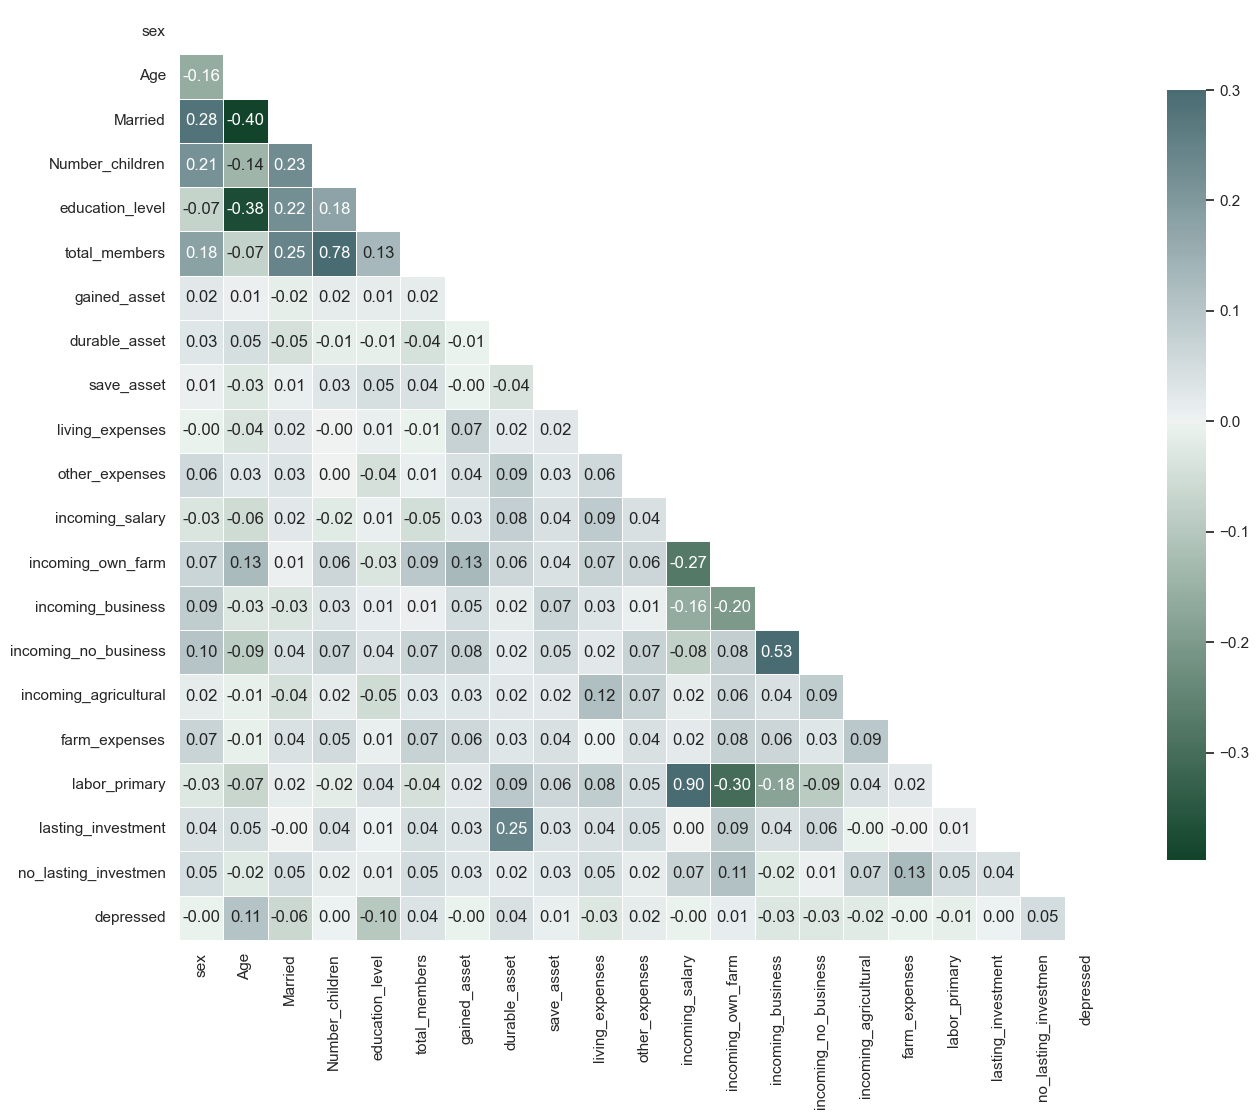

In [14]:
sns.set_theme(style="white")
corr=df.corr()
mask=np.triu(np.ones_like(corr,dtype=bool))
f,ax=plt.subplots(figsize=(15,20))
cmap=sns.diverging_palette(145,210,s=85,l=25,n=7,center="light",as_cmap=True)
sns.heatmap(corr,annot=True,fmt=".2f",mask=mask,cmap=cmap,vmax=.3,center=0,square=True,linewidths=.5,cbar_kws={"shrink":.5})

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1429 entries, 0 to 1428
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   sex                    1429 non-null   int64
 1   Age                    1429 non-null   int64
 2   Married                1429 non-null   int64
 3   Number_children        1429 non-null   int64
 4   education_level        1429 non-null   int64
 5   total_members          1429 non-null   int64
 6   gained_asset           1429 non-null   int64
 7   durable_asset          1429 non-null   int64
 8   save_asset             1429 non-null   int64
 9   living_expenses        1429 non-null   int64
 10  other_expenses         1429 non-null   int64
 11  incoming_salary        1429 non-null   int64
 12  incoming_own_farm      1429 non-null   int64
 13  incoming_business      1429 non-null   int64
 14  incoming_no_business   1429 non-null   int64
 15  incoming_agricultural  1429 non-null  

In [16]:
scaler = preprocessing.MinMaxScaler(feature_range=(0,1))
norm = scaler.fit_transform(newdf.iloc[:,[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19]])
norm_df = pd.DataFrame(norm,columns = ["sex","Age","Married","Number_children","education_level","total_members","gained_asset","durable_asset","save_asset","living_expenses",
                                    "other_expenses","incoming_salary","incoming_own_farm","incoming_business","incoming_no_business","incoming_agricultural","farm_expenses","labor_primary","lasting_investment","no_lasting_investmen"])
norm_df["depressed"] = newdf["depressed"]

In [17]:
x=norm_df.iloc[:,:19].values
y=norm_df["depressed"].values.reshape(-1,1)
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.2,random_state=0)

In [18]:
clf=DecisionTreeClassifier(criterion='gini', splitter='random', max_depth=4, min_samples_split=6, min_samples_leaf=2)
clf.fit(x_train,y_train.ravel())
y_pred=clf.predict(x_test)

In [ ]:
params = {
    'criterion':["gini", "entropy","log_loss"],
    'splitter':["best","random"],
    'max_depth': np.arange(1,5),
    'min_samples_split': np.arange(2,7),
    'min_samples_leaf': np.arange(1,7),
}


In [ ]:
gridSearch = GridSearchCV(estimator=clf, param_grid=params, refit="AUC" ,cv =5  )

In [ ]:
gridSearch

In [ ]:
gridSearch.fit(x_train, y_train)

In [ ]:
gridSearch.best_params_

In [19]:
print("Accuracy :",metrics.accuracy_score(y_test,y_pred))

Accuracy : 0.6729559748427673


In [20]:
print("Accuracy :",metrics.accuracy_score(y_train,clf.predict(x_train)))

Accuracy : 0.710236220472441


In [ ]:
feature_names=["battery_power","blue","clock_speed","dual_sim","fc","four_g","int_memory","m_dep","mobile_wt","n_cores",
                "pc","px_height","px_width","ram","sc_h","sc_w","talk_time","three_g","touch_screen","wifi","px","screen"]
target_names=["0","1","2","3"]
fig=plt.figure(figsize=(100,50))
plot=tree.plot_tree(clf,
                  feature_names=feature_names,
                  class_names=target_names,
                   filled=True)


In [21]:
print(classification_report(y,clf.predict(x)))

              precision    recall  f1-score   support

           0       0.64      0.92      0.76      1191
           1       0.85      0.49      0.62      1191

    accuracy                           0.70      2382
   macro avg       0.75      0.70      0.69      2382
weighted avg       0.75      0.70      0.69      2382



In [ ]:
actual=y
predicted=clf.predict(x)

confiusion_matrix=metrics.confusion_matrix(actual,predicted)
cm_display=metrics.ConfusionMatrixDisplay(confusion_matrix=confiusion_matrix)

cm_display.plot()
plt.show()

Random forest

In [22]:
clf1=RandomForestClassifier(n_estimators=300,criterion="entropy",max_depth=5,random_state=32,max_features=0.1)
clf1.fit(x_train,y_train.ravel())
y_pred=clf1.predict(x_test)

In [ ]:
params = {
    'n_estimators':[80,150,300],
    'criterion':["gini","entropy","log_loss"],
    'max_depth':[1,3,5],
    'random_state':[32,42],
    'max_features':[0.1,0.5,0.8],
}

In [ ]:
gridSearch = GridSearchCV(estimator=clf1, param_grid=params, refit="AUC" ,cv =5  )

In [ ]:
gridSearch

In [ ]:
gridSearch.fit(x_train, y_train)

In [ ]:
gridSearch.best_params_

In [23]:
print("Accuracy :",metrics.accuracy_score(y_test,y_pred))

Accuracy : 0.7735849056603774


In [24]:
print("Accuracy :",metrics.accuracy_score(y_train,clf.predict(x_train)))

Accuracy : 0.710236220472441


In [25]:
print(classification_report(y,clf1.predict(x)))

              precision    recall  f1-score   support

           0       0.84      0.77      0.80      1191
           1       0.79      0.85      0.82      1191

    accuracy                           0.81      2382
   macro avg       0.81      0.81      0.81      2382
weighted avg       0.81      0.81      0.81      2382



In [ ]:
actual=y
predicted=clf1.predict(x)

confiusion_matrix=metrics.confusion_matrix(actual,predicted)
cm_display=metrics.ConfusionMatrixDisplay(confusion_matrix=confiusion_matrix)

cm_display.plot()
plt.show()

SVM

In [26]:
clf2=SVC(C=0.1,kernel="linear",gamma="scale",random_state=24)
clf2.fit(x_train,y_train.ravel())
y_pred=clf2.predict(x_test)

In [ ]:
params = {
    'gamma':["scale","auto"],
    'kernel':["linear"," poly"," rbf","sigmoid"],
    'random_state': [24,32,42],
    'C': np.arange(0.1,0.9),
}

In [ ]:
gridSearch = GridSearchCV(estimator=clf2, param_grid=params, refit="AUC" ,cv =5  )

In [ ]:
gridSearch

In [ ]:
gridSearch.fit(x_train, y_train)

In [ ]:
gridSearch.best_params_

In [27]:
print("Accuracy :",metrics.accuracy_score(y_test,y_pred))

Accuracy : 0.750524109014675


In [28]:
print("Accuracy :",metrics.accuracy_score(y_train,clf2.predict(x_train)))

Accuracy : 0.7884514435695538


In [29]:
print(classification_report(y,clf2.predict(x)))

              precision    recall  f1-score   support

           0       0.79      0.77      0.78      1191
           1       0.78      0.79      0.78      1191

    accuracy                           0.78      2382
   macro avg       0.78      0.78      0.78      2382
weighted avg       0.78      0.78      0.78      2382



In [ ]:
actual=y
predicted=clf2.predict(x)

confiusion_matrix=metrics.confusion_matrix(actual,predicted)
cm_display=metrics.ConfusionMatrixDisplay(confusion_matrix=confiusion_matrix)

cm_display.plot()
plt.show()

Log Reg

In [30]:
logreg=LogisticRegression(solver="saga",penalty="l2",random_state=24,max_iter=100,C=0.08858667904100823,tol=0.1)
logreg.fit(x_train,y_train.ravel())
y_pred=logreg.predict(x_test)

In [ ]:
params = {
    'penalty':["l1", "l2"," elasticnet", None],
    'solver':["lbfgs", "liblinear", "newton-cg", "newton-cholesky", "sag", "saga"],
    'random_state':[24,32,42],
    'C': np.logspace(-4, 4, 20),
    'max_iter':[100, 1000,2500, 5000],
    'tol':np.arange(0.1,0.22,2),
}

In [ ]:
gridSearch = GridSearchCV(estimator=logreg, param_grid=params, refit="AUC" ,cv =5  )

In [ ]:
gridSearch

In [ ]:
gridSearch.fit(x_train, y_train)

In [ ]:
gridSearch.best_params_

In [31]:
print("Accuracy :",metrics.accuracy_score(y_test,y_pred))

Accuracy : 0.7358490566037735


In [ ]:
print(classification_report(y,logreg.predict(x)))

In [ ]:
actual=y
predicted=logreg.predict(x)

confiusion_matrix=metrics.confusion_matrix(actual,predicted)
cm_display=metrics.ConfusionMatrixDisplay(confusion_matrix=confiusion_matrix)

cm_display.plot()
plt.show()

MLP

In [32]:
clf5 = MLPClassifier(hidden_layer_sizes=(40,20,10),activation='relu',solver='adam', alpha=0.0001, batch_size='auto', learning_rate='constant', max_iter=200,random_state=None)

In [33]:
clf5.fit(x_train,y_train.ravel())
y_pred=clf5.predict(x_test)

In [ ]:
params = {
    #'solver':["lbfgs","sgd","adam"],
    'hidden_layer_sizes':[3,50,80,90,100],
    #'activation':["identity","logistic","tanh","relu"],
    'random_state':[0,24,32,42],
    'batch_size':[25,32,40],
    'max_iter':[100,200,300],
    'learning_rate':["constant","invscaling","adaptive"],
}

In [ ]:
gridSearch = GridSearchCV(estimator=clf5, param_grid=params, refit="AUC" ,cv =5  )

In [ ]:
gridSearch

In [ ]:
gridSearch.fit(x_train, y_train)

In [ ]:
gridSearch.best_params_

In [34]:
print("Accuracy :",metrics.accuracy_score(y_test,y_pred))

Accuracy : 0.779874213836478


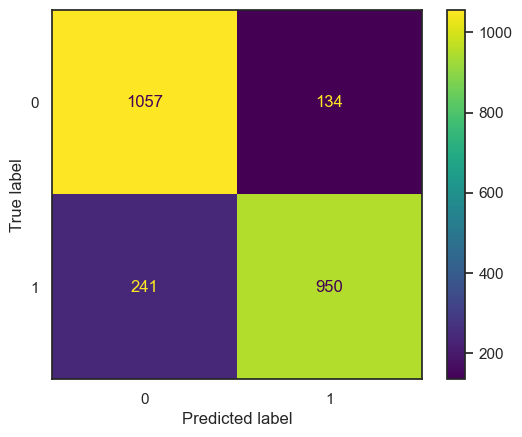

In [35]:
actual=y
predicted=clf5.predict(x)

confiusion_matrix=metrics.confusion_matrix(actual,predicted)
cm_display=metrics.ConfusionMatrixDisplay(confusion_matrix=confiusion_matrix)

cm_display.plot()
plt.show()